In [1]:
# PIP MODE: use the installed ras-commander package.
# For local source testing, run Jupyter with PYTHONPATH set to the repo root.

from pathlib import Path
import logging
import shutil

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import rasterio
from rasterio.enums import Resampling
from rasterio.windows import from_bounds
from shapely.geometry import box

from ras_commander import RasExamples, RasMap, RasCmdr, init_ras_project
from ras_commander.hdf import HdfLandCover, HdfResultsMesh

for logger_name in [
    "ras_commander.RasExamples",
    "ras_commander.RasMap",
    "ras_commander._land_classification_helper",
    "ras_commander.hdf.HdfBase",
    "ras_commander.hdf.HdfLandCover",
    "ras_commander.RasCmdr",
]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

## Developer Mode

When editing ras-commander locally, run this notebook from the repository root with `PYTHONPATH` set to that root before launching Jupyter or `nbconvert`. Restore this pip-mode import cell before committing.

# Land Classification Polygon Authoring

This notebook demonstrates the public `RasMap` API for adding sidecar classification polygons to a copied land-cover layer. The example writes two land-cover override polygons, assigns class IDs and Manning's n roughness values, reads them back through HDF helpers, and plots the override categories on the project land-cover raster.

In [2]:
PROJECT_NAME = "BaldEagleCrkMulti2D"
repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().resolve().name == "examples"
    else Path.cwd().resolve()
)
WORK_DIR = repo_root / "working" / "CLB-322_land_classification_polygon_authoring"
WORK_DIR.mkdir(parents=True, exist_ok=True)

project_path = RasExamples.extract_project(
    PROJECT_NAME,
    output_path=repo_root / "example_projects",
)
land_classification_layers = RasMap.list_land_classification_layers(project_path)
landcover_layers = RasMap.list_landcover_layers(project_path)
assert not landcover_layers.empty, "Expected a land-cover layer in the example project."

source_hdf = Path(landcover_layers.iloc[0]["resolved_path"])
source_tif = source_hdf.with_suffix(".tif")
assert source_hdf.exists(), source_hdf
assert source_tif.exists(), source_tif

copied_hdf = WORK_DIR / "LandCover_polygon_override_demo.hdf"
copied_tif = copied_hdf.with_suffix(".tif")
shutil.copy2(source_hdf, copied_hdf)
shutil.copy2(source_tif, copied_tif)

print(f"Project: {project_path}")
print(f"Copied sidecar HDF: {copied_hdf}")
print(f"Copied sidecar raster: {copied_tif}")

display(
    land_classification_layers[
        ["name", "classification_kind", "resolved_path"]
    ]
)
display(HdfLandCover.get_landcover_raster_map(copied_hdf).head(8))


Project: G:\GH\ras-commander\example_projects\BaldEagleCrkMulti2D
Copied sidecar HDF: G:\GH\ras-commander\working\CLB-322_land_classification_polygon_authoring\LandCover_polygon_override_demo.hdf
Copied sidecar raster: G:\GH\ras-commander\working\CLB-322_land_classification_polygon_authoring\LandCover_polygon_override_demo.tif


,name,classification_kind,resolved_path
0,LandCover,landcover,G:\GH\ras-commander\example_projects\BaldEagle...
1,Hydrologic Soil Groups,soils,G:\GH\ras-commander\example_projects\BaldEagle...
2,Infiltration,infiltration,G:\GH\ras-commander\example_projects\BaldEagle...


,pixel_value,class_name,mannings_n
0,0,NoData,0.035
1,43,Mixed Forest,0.120
2,41,Deciduous Forest,0.100
3,21,"Developed, Open Space",0.035
4,42,Evergreen Forest,0.150
5,11,Open Water,0.035
6,52,Shrub-Scrub,0.050
7,81,Pasture-Hay,0.045


In [3]:
base_polygons = RasMap.list_land_classification_polygons(copied_hdf)
if base_polygons.empty:
    with rasterio.open(copied_tif) as src:
        minx, miny, maxx, maxy = src.bounds
else:
    minx, miny, maxx, maxy = base_polygons.total_bounds

width = maxx - minx
height = maxy - miny
override_specs = [
    {
        "class_name": "Parking Lot",
        "class_id": 991,
        "mannings_n": 0.105,
        "percent_impervious": 95.0,
        "geometry": box(
            minx + 0.18 * width,
            miny + 0.38 * height,
            minx + 0.30 * width,
            miny + 0.48 * height,
        ),
    },
    {
        "class_name": "Riparian Brush",
        "class_id": 992,
        "mannings_n": 0.070,
        "percent_impervious": 15.0,
        "geometry": box(
            minx + 0.55 * width,
            miny + 0.58 * height,
            minx + 0.67 * width,
            miny + 0.70 * height,
        ),
    },
]

last_result = None
for spec in override_specs:
    last_result = RasMap.add_land_classification_polygon(
        copied_hdf,
        spec["geometry"],
        class_name=spec["class_name"],
        class_id=spec["class_id"],
        variable_values={
            "mannings_n": spec["mannings_n"],
            "percent_impervious": spec["percent_impervious"],
        },
    )

assert last_result is not None
assert last_result.attrs["recompute_required"] is True

polygons = HdfLandCover.get_classification_polygons(copied_hdf)
class_map = HdfLandCover.get_landcover_raster_map(copied_hdf)
created_names = [spec["class_name"] for spec in override_specs]
summary = polygons.loc[polygons["class_name"].isin(created_names)].merge(
    class_map[["pixel_value", "class_name", "mannings_n"]],
    on="class_name",
    how="left",
)
summary["area_sq_ft"] = summary.geometry.area

display(
    summary[
        [
            "polygon_index",
            "class_name",
            "pixel_value",
            "mannings_n",
            "area_sq_ft",
        ]
    ]
)
print(f"Total classification polygons in copied sidecar: {len(polygons)}")
print(f"Recompute required after sidecar edit: {last_result.attrs['recompute_required']}")
print(f"Backup HDF: {last_result.attrs['backup_path']}")


,polygon_index,class_name,pixel_value,mannings_n,area_sq_ft
0,1,Parking Lot,991,0.105,4.236943e+07
1,2,Riparian Brush,992,0.070,5.084332e+07


Total classification polygons in copied sidecar: 3
Recompute required after sidecar edit: True
Backup HDF: G:\GH\ras-commander\working\CLB-322_land_classification_polygon_authoring\LandCover_polygon_override_demo.hdf.bak


Saved map figure: G:\GH\ras-commander\working\CLB-322_land_classification_polygon_authoring\land_classification_polygon_authoring.png


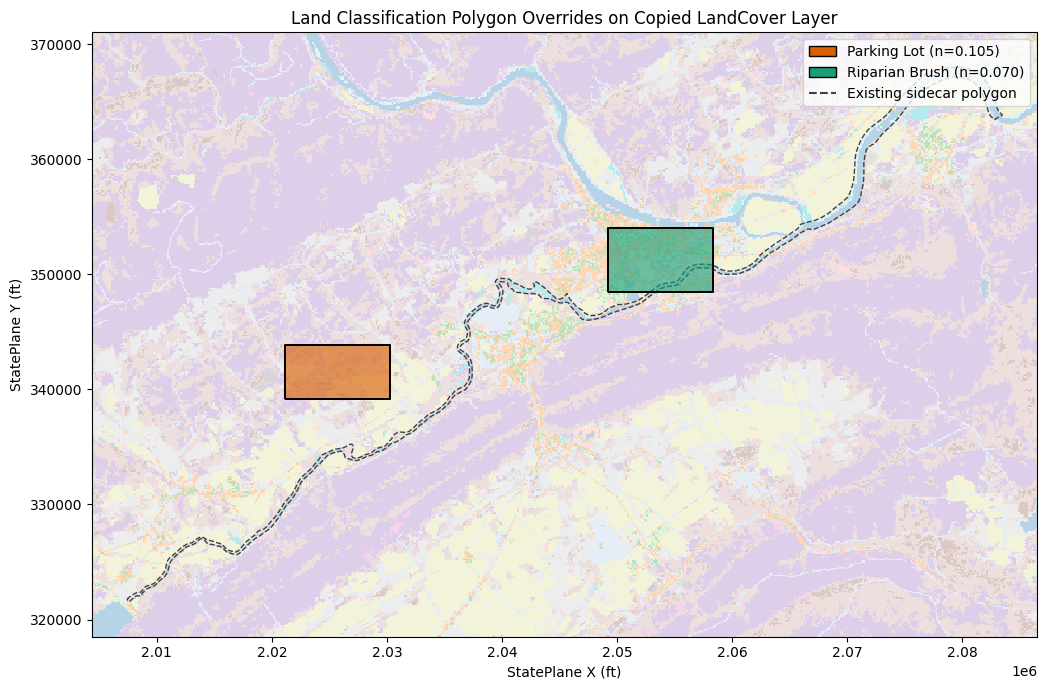

In [4]:
plot_polygons = polygons.loc[polygons["class_name"].isin(created_names)].copy()
context_polygons = polygons.loc[~polygons["class_name"].isin(created_names)].copy()
plot_minx, plot_miny, plot_maxx, plot_maxy = polygons.total_bounds
padding = max(plot_maxx - plot_minx, plot_maxy - plot_miny) * 0.04

with rasterio.open(copied_tif) as src:
    window = from_bounds(
        plot_minx - padding,
        plot_miny - padding,
        plot_maxx + padding,
        plot_maxy + padding,
        transform=src.transform,
    ).round_offsets().round_lengths()
    scale = max(1, int(max(window.width, window.height) // 1100))
    out_height = max(1, int(window.height // scale))
    out_width = max(1, int(window.width // scale))
    landcover_window = src.read(
        1,
        window=window,
        out_shape=(out_height, out_width),
        resampling=Resampling.nearest,
    )
    transform = src.window_transform(window) * src.transform.scale(
        window.width / out_width,
        window.height / out_height,
    )

left, top = transform * (0, 0)
right, bottom = transform * (landcover_window.shape[1], landcover_window.shape[0])
extent = (left, right, bottom, top)

unique_values = np.unique(landcover_window)
value_to_index = {value: index for index, value in enumerate(unique_values)}
indexed_window = np.vectorize(value_to_index.get)(landcover_window)
base_cmap = ListedColormap(
    plt.cm.tab20(np.linspace(0, 1, max(len(unique_values), 1)))
)

override_colors = {
    "Parking Lot": "#d95f02",
    "Riparian Brush": "#1b9e77",
}
n_lookup = dict(zip(class_map["class_name"], class_map["mannings_n"]))

fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(
    indexed_window,
    cmap=base_cmap,
    extent=extent,
    origin="upper",
    interpolation="nearest",
    alpha=0.32,
)

if not context_polygons.empty:
    context_polygons.plot(
        ax=ax,
        facecolor="none",
        edgecolor="0.25",
        linewidth=1.0,
        linestyle="--",
    )

for class_name, color in override_colors.items():
    selected = plot_polygons.loc[plot_polygons["class_name"] == class_name]
    selected.plot(
        ax=ax,
        facecolor=color,
        edgecolor="black",
        linewidth=1.2,
        alpha=0.62,
    )
    selected.geometry.boundary.plot(ax=ax, color="black", linewidth=1.4)

handles = [
    Patch(
        facecolor=color,
        edgecolor="black",
        label=f"{class_name} (n={n_lookup[class_name]:.3f})",
    )
    for class_name, color in override_colors.items()
]
if not context_polygons.empty:
    handles.append(
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle="--",
            label="Existing sidecar polygon",
        )
    )

ax.legend(handles=handles, loc="upper right", frameon=True)
ax.set_title("Land Classification Polygon Overrides on Copied LandCover Layer")
ax.set_xlabel("StatePlane X (ft)")
ax.set_ylabel("StatePlane Y (ft)")
ax.set_aspect("equal")
fig.tight_layout()

figure_path = WORK_DIR / "land_classification_polygon_authoring.png"
fig.savefig(figure_path, dpi=160)
print(f"Saved map figure: {figure_path}")
plt.show()


In [5]:
def _decode(value):
    return value.decode("utf-8").strip() if isinstance(value, bytes) else value


with h5py.File(copied_hdf, "r") as hdf_file:
    polygon_attrs = hdf_file["Classification Polygons/Attributes"][()]
    polygon_info = hdf_file["Classification Polygons/Polygon Info"][()]
    polygon_points = hdf_file["Classification Polygons/Polygon Points"][()]
    variables = hdf_file["Variables"][()]
    raster_map = hdf_file["Raster Map"][()]

audit = pd.DataFrame(
    [
        {
            "dataset": "Classification Polygons/Attributes",
            "rows": len(polygon_attrs),
            "fields": list(polygon_attrs.dtype.names),
        },
        {
            "dataset": "Classification Polygons/Polygon Info",
            "rows": len(polygon_info),
            "fields": ["point_start", "point_count", "part_start", "part_count"],
        },
        {
            "dataset": "Classification Polygons/Polygon Points",
            "rows": len(polygon_points),
            "fields": ["x", "y"],
        },
        {
            "dataset": "Raster Map",
            "rows": len(raster_map),
            "fields": list(raster_map.dtype.names),
        },
        {
            "dataset": "Variables",
            "rows": len(variables),
            "fields": list(variables.dtype.names),
        },
    ]
)
attribute_classes = pd.DataFrame(
    {
        "classification_polygon_class": [
            _decode(row["Classification"]) for row in polygon_attrs
        ]
    }
)

display(audit)
display(attribute_classes)
display(class_map.loc[class_map["class_name"].isin(created_names)])


,dataset,rows,fields
0,Classification Polygons/Attributes,3,[Classification]
1,Classification Polygons/Polygon Info,3,"[point_start, point_count, part_start, part_co..."
2,Classification Polygons/Polygon Points,728,"[x, y]"
3,Raster Map,18,"[ID, Name]"
4,Variables,19,"[Name, ManningsN, Percent Impervious]"


,classification_polygon_class
0,Main Channel
1,Parking Lot
2,Riparian Brush


,pixel_value,class_name,mannings_n
16,991,Parking Lot,0.105
17,992,Riparian Brush,0.070


## Preprocessing Pipeline

The sidecar HDF now contains the classification polygon records, raster class map,
and Manning's n variable assignments written by the public API. To compile these
into per-cell Manning's n values in the geometry HDF:

1. **Associate** the sidecar layer with the geometry via RAS Mapper or
   `RasMap.associate_geometry_layers()` / `GeomMesh.set_geometry_association()`.
2. **Preprocess** through RAS Mapper GUI — the command-line geometry preprocessor
   does not resample landcover classification polygons into per-cell roughness.
3. **Compute** the plan — the solver reads per-cell Manning's n from the
   computational preprocessor output, not directly from the geometry HDF.

The `recompute_required=True` flag returned by the writer signals that the
geometry needs reprocessing before the new classification polygons take effect.

## Manning's n Verification

Verify that the geometry HDF's per-cell Manning's n reflects landcover-based
roughness values, and that the sidecar API's override Manning's n values are
consistent with the project's calibration table.

The pre-built geometry HDF (from RAS Mapper preprocessing) contains spatially
varying Manning's n derived from the landcover raster and calibration table.
The command-line solver reads these values from the computational preprocessor
output. Full resampling of sidecar classification polygons into per-cell
roughness requires RAS Mapper GUI preprocessing — this section validates the
data pipeline rather than the compute pipeline.

In [6]:
PLAN_NUMBER = "06"
WSE_COL = "maximum_water_surface"

project_path = RasExamples.extract_project(
    PROJECT_NAME, output_path=repo_root / "example_projects"
)
prj = init_ras_project(project_path, ras_version="6.6")

plan_row = prj.plan_df[prj.plan_df["plan_number"] == PLAN_NUMBER].iloc[0]
geom_number = plan_row["geometry_number"]
geom_hdf = project_path / f"BaldEagleDamBrk.g{geom_number}.hdf"
nkey = f"Geometry/2D Flow Areas/BaldEagleCr/Cells Center Manning's n"
cal_key = "Geometry/Land Cover (Manning's n)/Calibration Table"

with h5py.File(str(geom_hdf), "r") as f:
    per_cell_n = f[nkey][:]
    cal_table = f[cal_key][:]
    centers = f["Geometry/2D Flow Areas/BaldEagleCr/Cells Center Coordinate"][:]

cal_df = pd.DataFrame(
    [
        {
            "class_name": row[0].decode().strip() if isinstance(row[0], bytes) else str(row[0]),
            "base_n": float(row[1]),
            "main_ch_n": float(row[2]),
        }
        for row in cal_table
    ]
)
cal_df = cal_df[cal_df["class_name"] != ""]

print(f"Plan p{PLAN_NUMBER}: {plan_row['Plan Title']}")
print(f"Geometry HDF: {geom_hdf.name}")
print(f"Total mesh cells: {len(per_cell_n)}")
print(f"Per-cell Manning's n range: [{per_cell_n.min():.3f}, {per_cell_n.max():.3f}]")
print(f"Unique values: {np.unique(per_cell_n)}")
print(f"\nCalibration table ({len(cal_df)} classes):")
display(cal_df)

2026-05-02 00:39:48 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 7.0 at C:\Program Files (x86)\HEC\HEC-RAS\7.0\Ras.exe via filesystem (x86)


2026-05-02 00:39:48 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.7 Beta 5 at C:\Program Files (x86)\HEC\HEC-RAS\6.7 Beta 5\Ras.exe via filesystem (x86)


2026-05-02 00:39:48 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.5 at C:\Program Files (x86)\HEC\HEC-RAS\6.5\Ras.exe via filesystem (x86)


2026-05-02 00:39:48 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.3.1 at C:\Program Files (x86)\HEC\HEC-RAS\6.3.1\Ras.exe via filesystem (x86)


2026-05-02 00:39:48 - ras_commander.RasUtils - INFO - Discovered HEC-RAS 6.2 at C:\Program Files (x86)\HEC\HEC-RAS\6.2\Ras.exe via filesystem (x86)


...

2026-05-02 00:39:49 - ras_commander.RasPrj - INFO - ras-commander v0.96.1 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://ras-commander.readthedocs.io | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-05-02 00:39:49 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk | Folder: G:\GH\ras-commander\example_projects\BaldEagleCrkMulti2D


2026-05-02 00:39:49 - ras_commander.RasPrj - INFO - Using HEC-RAS executable: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


Plan p06: Gridded Precip - Infiltration
Geometry HDF: BaldEagleDamBrk.g09.hdf
Total mesh cells: 19597
Per-cell Manning's n range: [0.030, 0.150]
Unique values: [0.03  0.035 0.04  0.045 0.05  0.06  0.08  0.1   0.12  0.15 ]

Calibration table (16 classes):


,class_name,base_n,main_ch_n
1,NoData,0.060,0.04
2,Barren Land Rock/Sand/Clay,0.040,0.04
3,Cultivated Crops,0.060,0.04
4,Deciduous Forest,0.100,0.04
5,"Developed, High Intensity",0.150,0.04
6,"Developed, Low Intensity",0.100,0.04
7,"Developed, Medium Intensity",0.080,0.04
8,"Developed, Open Space",0.040,0.04
9,Emergent Herbaceous Wetlands,0.080,0.04
10,Evergreen Forest,0.120,0.04


In [7]:
override_n_values = {spec["class_name"]: spec["mannings_n"] for spec in override_specs}
cal_n_values = dict(zip(cal_df["class_name"], cal_df["base_n"]))

print("Override polygon Manning's n vs calibration table:\n")
print(f"{'Override Class':<20s} {'Override n':>10s} {'Nearest Cal Class':<30s} {'Cal n':>8s}")
print("-" * 72)
for name, n in override_n_values.items():
    closest_name = min(cal_n_values, key=lambda k: abs(cal_n_values[k] - n))
    closest_n = cal_n_values[closest_name]
    print(f"{name:<20s} {n:>10.3f} {closest_name:<30s} {closest_n:>8.3f}")

n_values_in_cells, n_counts = np.unique(per_cell_n, return_counts=True)
print(f"\nPer-cell Manning's n distribution ({len(per_cell_n)} cells):")
for val, count in sorted(zip(n_values_in_cells, n_counts), key=lambda x: -x[1]):
    pct = count / len(per_cell_n) * 100
    matching = cal_df.loc[
        (cal_df["base_n"] == val) | (cal_df["main_ch_n"] == val), "class_name"
    ].tolist()
    classes = ", ".join(matching) if matching else "(default or interpolated)"
    print(f"  n={val:.3f}: {count:>6d} cells ({pct:>5.1f}%)  ← {classes}")

cells_inside = 0
for spec in override_specs:
    bminx, bminy, bmaxx, bmaxy = spec["geometry"].bounds
    mask = (
        (centers[:, 0] >= bminx) & (centers[:, 0] <= bmaxx)
        & (centers[:, 1] >= bminy) & (centers[:, 1] <= bmaxy)
    )
    count = mask.sum()
    cells_inside += count
    existing_n = per_cell_n[mask]
    print(
        f"\n{spec['class_name']} footprint: {count} cells, "
        f"current mean n={existing_n.mean():.3f}, "
        f"proposed n={spec['mannings_n']:.3f}, "
        f"delta={spec['mannings_n'] - existing_n.mean():+.3f}"
    )

print(f"\nTotal cells affected by override polygons: {cells_inside} / {len(per_cell_n)}")

Override polygon Manning's n vs calibration table:

Override Class       Override n Nearest Cal Class                 Cal n
------------------------------------------------------------------------
Parking Lot               0.105 Deciduous Forest                  0.100
Riparian Brush            0.070 Developed, Medium Intensity       0.080

Per-cell Manning's n distribution (19597 cells):
  n=0.080:   4785 cells ( 24.4%)  ← Developed, Medium Intensity, Emergent Herbaceous Wetlands, Mixed Forest, Shrub/Scrub
  n=0.060:   3802 cells ( 19.4%)  ← NoData, Cultivated Crops, Pasture/Hay
  n=0.100:   3581 cells ( 18.3%)  ← Deciduous Forest, Developed, Low Intensity
  n=0.035:   2403 cells ( 12.3%)  ← Open Water
  n=0.040:   2369 cells ( 12.1%)  ← NoData, Barren Land Rock/Sand/Clay, Cultivated Crops, Deciduous Forest, Developed, High Intensity, Developed, Low Intensity, Developed, Medium Intensity, Developed, Open Space, Emergent Herbaceous Wetlands, Evergreen Forest, Grassland/Herbaceous, Mixed

Saved Manning's n figure: G:\GH\ras-commander\working\CLB-322_land_classification_polygon_authoring\mannings_n_spatial.png


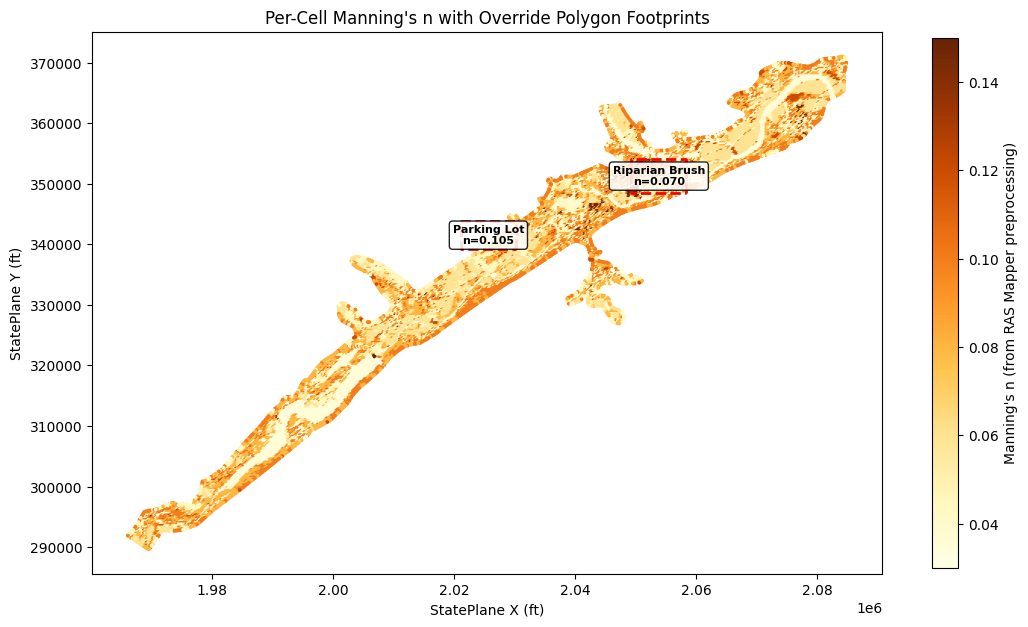

In [8]:
fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    centers[:, 0], centers[:, 1],
    c=per_cell_n, cmap="YlOrBr", s=3, vmin=0.03, vmax=0.15
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Manning's n (from RAS Mapper preprocessing)")

for spec in override_specs:
    ex_x, ex_y = spec["geometry"].exterior.xy
    ax.plot(ex_x, ex_y, color="red", linewidth=2, linestyle="--")
    cx, cy = spec["geometry"].centroid.coords[0]
    ax.annotate(
        f"{spec['class_name']}\nn={spec['mannings_n']:.3f}",
        xy=(cx, cy), ha="center", va="center", fontsize=8,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85),
    )

ax.set_title("Per-Cell Manning's n with Override Polygon Footprints")
ax.set_xlabel("StatePlane X (ft)")
ax.set_ylabel("StatePlane Y (ft)")
ax.set_aspect("equal")
fig.tight_layout()

mannings_figure = WORK_DIR / "mannings_n_spatial.png"
fig.savefig(mannings_figure, dpi=160)
print(f"Saved Manning's n figure: {mannings_figure}")
plt.show()